# XGBoost Classification for TLS Profiling

This notebook evaluates a supervised XGBoost baseline on extracted TLS traffic features. The dataset paths are parameterized so the same experiment can be run on one or more parquet partitions. Unlike the anomaly-detection baselines, this model is trained to classify each flow directly into one of four categories: `system`, `malware`, `application`, or `unknown`.


In [1]:
import sys
from pathlib import Path
sys.path.append('../../src')

### PARAMETERS:


In [2]:
train_features_path = ["../data-ext/malware_train.parquet", "../data-ext/apps_train.parquet"]
val_features_path = ["../data-ext/malware_val.parquet", "../data-ext/apps_val.parquet"]
test_features_path = ["../data-ext/malware_test.parquet", "../data-ext/apps_test.parquet"]
train_labels_path = ["../data-ext/malware_train_labels.parquet", "../data-ext/apps_train_labels.parquet"]
val_labels_path = ["../data-ext/malware_val_labels.parquet", "../data-ext/apps_val_labels.parquet"]
test_labels_path = ["../data-ext/malware_test_labels.parquet", "../data-ext/apps_test_labels.parquet"]


## Feature Groups

- `FLOW`: basic bidirectional flow statistics such as bytes, packets, rates, and duration (`bs`, `ps`, `br`, `pr`, `td`)
- `CTLS`: client-side TLS metadata (`tls.cver`, `tls.ccs`, `tls.cext`, `tls.csg`, `tls.alpn`, `tls.csv`)
- `STLS`: server-side TLS metadata (`tls.sver`, `tls.scs`, `tls.sext`, `tls.ssv`)
- `REC`: ordered sequence of signed TLS record lengths (`tls.rec`, first 20 records)

The experiments below sweep over every non-empty combination of these groups.


In [3]:
feature_groups = {
    "FLOW": ["bs", "ps", "br", "pr", "td"],
    "CTLS": ["tls.cver", "tls.ccs", "tls.cext", "tls.csg", "tls.alpn", "tls.csv"],
    "STLS": ["tls.sver", "tls.scs", "tls.sext", "tls.ssv"],
    "REC": ["tls.rec"],
}

FLOW = feature_groups["FLOW"]
CTLS = feature_groups["CTLS"]
STLS = feature_groups["STLS"]
REC = feature_groups["REC"]


In [4]:
import pandas as pd
from pathlib import Path
from tls_profiling.preprocessing import build_and_fit_preprocessor

def read_parquet_files(paths):
    if isinstance(paths, (str, Path)):
        paths = [paths]
    return pd.concat([pd.read_parquet(Path(path)) for path in paths], ignore_index=True)

print("Loading extracted features from parameterized parquet paths.")
df_train = read_parquet_files(train_features_path)
df_val = read_parquet_files(val_features_path)
df_test = read_parquet_files(test_features_path)
df_train_label = read_parquet_files(train_labels_path)
df_val_label = read_parquet_files(val_labels_path)
df_test_label = read_parquet_files(test_labels_path)

preprocessor = build_and_fit_preprocessor(df_train)
print("Built preprocessor from df_train.")


Loading extracted features from parameterized parquet paths.


Built preprocessor from df_train.


In [5]:
from tls_profiling.baselines.model_xgboost import XGBoostBaseline, Config
import numpy as np

from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

CLASS_NAMES = ["system", "malware", "application", "unknown"]
CLASS_TO_INDEX = {label: idx for idx, label in enumerate(CLASS_NAMES)}
INDEX_TO_CLASS = {idx: label for label, idx in CLASS_TO_INDEX.items()}

XGB_CONFIG_CANDIDATES = {
    "balanced_hist_deep": Config(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        min_child_weight=1.0,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        max_train_samples=100_000,
    ),
    "balanced_hist_shallow": Config(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.08,
        min_child_weight=2.0,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_lambda=1.0,
        max_train_samples=100_000,
    ),
}

def encode_labels(series: pd.Series) -> np.ndarray:
    return series.map(CLASS_TO_INDEX).to_numpy(dtype=np.int64)

def decode_labels(values: np.ndarray) -> list[str]:
    return [INDEX_TO_CLASS[int(value)] for value in values]

def select_feature_set(x, feature_set):
    if not feature_set:
        return x

    selected_columns = [
        column for column in x.columns
        if any(column.startswith(prefix) for prefix in feature_set)
    ]
    return x.loc[:, selected_columns]

def compute_multiclass_scores(y_true, y_pred, y_score):
    y_true_bin = label_binarize(y_true, classes=np.arange(len(CLASS_NAMES)))
    per_class_f1 = f1_score(
        y_true,
        y_pred,
        average=None,
        labels=np.arange(len(CLASS_NAMES)),
    )

    return {
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "macro_auc": roc_auc_score(
            y_true,
            y_score,
            labels=np.arange(len(CLASS_NAMES)),
            multi_class="ovr",
            average="macro",
        ),
        "macro_ap": average_precision_score(y_true_bin, y_score, average="macro"),
        "system_f1": per_class_f1[CLASS_TO_INDEX["system"]],
        "malware_f1": per_class_f1[CLASS_TO_INDEX["malware"]],
        "application_f1": per_class_f1[CLASS_TO_INDEX["application"]],
        "unknown_f1": per_class_f1[CLASS_TO_INDEX["unknown"]],
    }

def choose_best_model(x_train, y_train, x_val, y_val):
    best_name = None
    best_model = None
    best_val_macro_f1 = -np.inf

    for config_name, config in XGB_CONFIG_CANDIDATES.items():
        model = XGBoostBaseline(config)
        model.fit(x_train, y_train)

        val_pred = model.predict(x_val)
        val_macro_f1 = f1_score(y_val, val_pred, average="macro")

        if val_macro_f1 > best_val_macro_f1:
            best_name = config_name
            best_model = model
            best_val_macro_f1 = val_macro_f1

    return best_name, best_model, float(best_val_macro_f1)

def evaluate(feature_set):
    y_train = encode_labels(df_train_label["category"])
    y_val = encode_labels(df_val_label["category"])
    y_test = encode_labels(df_test_label["category"])

    x_train_transformed = select_feature_set(preprocessor.transform(df_train), feature_set)
    x_val_transformed = select_feature_set(preprocessor.transform(df_val), feature_set)
    x_test_transformed = select_feature_set(preprocessor.transform(df_test), feature_set)

    best_config_name, model, val_macro_f1 = choose_best_model(
        x_train_transformed,
        y_train,
        x_val_transformed,
        y_val,
    )

    y_pred = model.predict(x_test_transformed)
    y_score = model.predict_proba(x_test_transformed)

    return y_test, y_pred, y_score, val_macro_f1, best_config_name

def debug_csv(feature_set, y_test, y_pred, y_score):
    feature_set_name = "_".join(feature_set)
    output_path = f"tmp/xgb_{feature_set_name}.csv"

    pd.DataFrame({
        "y_test": decode_labels(y_test),
        "y_pred": decode_labels(y_pred),
        "p_system": y_score[:, CLASS_TO_INDEX["system"]],
        "p_malware": y_score[:, CLASS_TO_INDEX["malware"]],
        "p_application": y_score[:, CLASS_TO_INDEX["application"]],
        "p_unknown": y_score[:, CLASS_TO_INDEX["unknown"]],
    }).to_csv(output_path, index=False)

def compute_scores(feature_set):
    y_test, y_pred, y_score, val_macro_f1, best_config_name = evaluate(feature_set)
    scores = compute_multiclass_scores(y_test, y_pred, y_score)

    debug_csv(feature_set, y_test, y_pred, y_score)
    return {
        "best_config": best_config_name,
        "val_macro_f1": val_macro_f1,
        **scores,
    }


## Evaluation

This baseline uses the same train, validation, and test splits as the anomaly-detection notebooks, but the task is now multiclass classification rather than one-class profiling.

Protocol:

- `train`: fit XGBoost on labeled traffic from all target categories
- `val`: select the best hyperparameter configuration using macro F1
- `test`: report multiclass metrics for the selected configuration on held-out traffic

The target classes in this notebook are `system`, `malware`, `application`, and `unknown`.


In [6]:
from itertools import combinations

rows = []

group_names = list(feature_groups)
for size in range(1, len(group_names) + 1):
    for group_combo in combinations(group_names, size):
        selected_features = []
        for group_name in group_combo:
            selected_features.extend(feature_groups[group_name])

        feature_set_name = ", ".join(group_combo)
        scores = compute_scores(selected_features)

        rows.append({
            "FeatureSet": feature_set_name,
            "BestConfig": scores["best_config"],
            "ValMacroF1": scores["val_macro_f1"],
            "MacroF1": scores["macro_f1"],
            "MacroAucScore": scores["macro_auc"],
            "MacroApScore": scores["macro_ap"],
            "SystemF1": scores["system_f1"],
            "MalwareF1": scores["malware_f1"],
            "ApplicationF1": scores["application_f1"],
            "UnknownF1": scores["unknown_f1"],
        })

results_df = pd.DataFrame(
    rows,
    columns=[
        "FeatureSet",
        "BestConfig",
        "ValMacroF1",
        "MacroF1",
        "MacroAucScore",
        "MacroApScore",
        "SystemF1",
        "MalwareF1",
        "ApplicationF1",
        "UnknownF1",
    ],
)
display(results_df)


,FeatureSet,BestConfig,ValMacroF1,MacroF1,MacroAucScore,MacroApScore,SystemF1,MalwareF1,ApplicationF1,UnknownF1
0,FLOW,balanced_hist_deep,0.724612,0.669494,0.953482,0.777129,0.942447,0.843354,0.288854,0.603319
1,CTLS,balanced_hist_shallow,0.504552,0.480752,0.823955,0.507338,0.867981,0.826219,0.098246,0.130563
2,STLS,balanced_hist_shallow,0.531954,0.487333,0.844411,0.572047,0.814180,0.650748,0.065096,0.419309
3,REC,balanced_hist_deep,0.746202,0.656012,0.964545,0.822828,0.934965,0.794108,0.209576,0.685398
4,"FLOW, CTLS",balanced_hist_deep,0.762225,0.711024,0.961727,0.832416,0.947677,0.841700,0.469217,0.585502
5,"FLOW, STLS",balanced_hist_deep,0.751873,0.675773,0.957950,0.796282,0.950015,0.840353,0.292563,0.620160
6,"FLOW, REC",balanced_hist_deep,0.790763,0.697006,0.968478,0.862020,0.939223,0.829207,0.363437,0.656154
7,"CTLS, STLS",balanced_hist_deep,0.589999,0.575846,0.889551,0.632371,0.817161,0.864169,0.152909,0.469144
8,"CTLS, REC",balanced_hist_deep,0.776490,0.708621,0.967368,0.854421,0.935176,0.839607,0.399069,0.660633
9,"STLS, REC",balanced_hist_deep,0.764145,0.661516,0.965707,0.830176,0.936665,0.795860,0.223625,0.689915


## Overall Results

The table below ranks feature sets by `MacroF1`, which is the primary metric for this multiclass baseline. `MacroAucScore` and `MacroApScore` are included to make the supervised baseline easier to compare at a high level with the anomaly-detection notebooks.


In [7]:
overall_df = results_df.sort_values("MacroF1", ascending=False)
display(overall_df)

,FeatureSet,BestConfig,ValMacroF1,MacroF1,MacroAucScore,MacroApScore,SystemF1,MalwareF1,ApplicationF1,UnknownF1
14,"FLOW, CTLS, STLS, REC",balanced_hist_deep,0.804093,0.757293,0.969058,0.875166,0.939098,0.848105,0.583778,0.658193
11,"FLOW, CTLS, REC",balanced_hist_deep,0.800486,0.752187,0.969593,0.868620,0.938352,0.853195,0.553623,0.663580
10,"FLOW, CTLS, STLS",balanced_hist_deep,0.779102,0.729874,0.965110,0.843827,0.952353,0.840512,0.532768,0.593865
13,"CTLS, STLS, REC",balanced_hist_deep,0.789590,0.721125,0.967306,0.857788,0.935891,0.849012,0.422704,0.676894
4,"FLOW, CTLS",balanced_hist_deep,0.762225,0.711024,0.961727,0.832416,0.947677,0.841700,0.469217,0.585502
8,"CTLS, REC",balanced_hist_deep,0.776490,0.708621,0.967368,0.854421,0.935176,0.839607,0.399069,0.660633
6,"FLOW, REC",balanced_hist_deep,0.790763,0.697006,0.968478,0.862020,0.939223,0.829207,0.363437,0.656154
12,"FLOW, STLS, REC",balanced_hist_deep,0.795552,0.688802,0.968733,0.863975,0.940861,0.825274,0.317017,0.672056
5,"FLOW, STLS",balanced_hist_deep,0.751873,0.675773,0.957950,0.796282,0.950015,0.840353,0.292563,0.620160
0,FLOW,balanced_hist_deep,0.724612,0.669494,0.953482,0.777129,0.942447,0.843354,0.288854,0.603319


## System Category

This table isolates how well each feature set classifies the `system` category. A high `SystemF1` means the supervised classifier can separate system traffic cleanly from both malware and application traffic.


In [8]:
system_df = results_df.sort_values("SystemF1", ascending=False)
display(system_df)

,FeatureSet,BestConfig,ValMacroF1,MacroF1,MacroAucScore,MacroApScore,SystemF1,MalwareF1,ApplicationF1,UnknownF1
10,"FLOW, CTLS, STLS",balanced_hist_deep,0.779102,0.729874,0.965110,0.843827,0.952353,0.840512,0.532768,0.593865
5,"FLOW, STLS",balanced_hist_deep,0.751873,0.675773,0.957950,0.796282,0.950015,0.840353,0.292563,0.620160
4,"FLOW, CTLS",balanced_hist_deep,0.762225,0.711024,0.961727,0.832416,0.947677,0.841700,0.469217,0.585502
0,FLOW,balanced_hist_deep,0.724612,0.669494,0.953482,0.777129,0.942447,0.843354,0.288854,0.603319
12,"FLOW, STLS, REC",balanced_hist_deep,0.795552,0.688802,0.968733,0.863975,0.940861,0.825274,0.317017,0.672056
6,"FLOW, REC",balanced_hist_deep,0.790763,0.697006,0.968478,0.862020,0.939223,0.829207,0.363437,0.656154
14,"FLOW, CTLS, STLS, REC",balanced_hist_deep,0.804093,0.757293,0.969058,0.875166,0.939098,0.848105,0.583778,0.658193
11,"FLOW, CTLS, REC",balanced_hist_deep,0.800486,0.752187,0.969593,0.868620,0.938352,0.853195,0.553623,0.663580
9,"STLS, REC",balanced_hist_deep,0.764145,0.661516,0.965707,0.830176,0.936665,0.795860,0.223625,0.689915
13,"CTLS, STLS, REC",balanced_hist_deep,0.789590,0.721125,0.967306,0.857788,0.935891,0.849012,0.422704,0.676894


## Malware Category

This section focuses on the `malware` class. Strong `MalwareF1` values indicate that the selected feature family helps XGBoost carve out malware traffic as a distinct supervised class rather than only separating it from one chosen normal profile.


In [9]:
malware_df = results_df.sort_values("MalwareF1", ascending=False)
display(malware_df)


,FeatureSet,BestConfig,ValMacroF1,MacroF1,MacroAucScore,MacroApScore,SystemF1,MalwareF1,ApplicationF1,UnknownF1
7,"CTLS, STLS",balanced_hist_deep,0.589999,0.575846,0.889551,0.632371,0.817161,0.864169,0.152909,0.469144
11,"FLOW, CTLS, REC",balanced_hist_deep,0.800486,0.752187,0.969593,0.868620,0.938352,0.853195,0.553623,0.663580
13,"CTLS, STLS, REC",balanced_hist_deep,0.789590,0.721125,0.967306,0.857788,0.935891,0.849012,0.422704,0.676894
14,"FLOW, CTLS, STLS, REC",balanced_hist_deep,0.804093,0.757293,0.969058,0.875166,0.939098,0.848105,0.583778,0.658193
0,FLOW,balanced_hist_deep,0.724612,0.669494,0.953482,0.777129,0.942447,0.843354,0.288854,0.603319
4,"FLOW, CTLS",balanced_hist_deep,0.762225,0.711024,0.961727,0.832416,0.947677,0.841700,0.469217,0.585502
10,"FLOW, CTLS, STLS",balanced_hist_deep,0.779102,0.729874,0.965110,0.843827,0.952353,0.840512,0.532768,0.593865
5,"FLOW, STLS",balanced_hist_deep,0.751873,0.675773,0.957950,0.796282,0.950015,0.840353,0.292563,0.620160
8,"CTLS, REC",balanced_hist_deep,0.776490,0.708621,0.967368,0.854421,0.935176,0.839607,0.399069,0.660633
6,"FLOW, REC",balanced_hist_deep,0.790763,0.697006,0.968478,0.862020,0.939223,0.829207,0.363437,0.656154


## Application Category

This section focuses on the `application` class. Strong `ApplicationF1` values indicate that the selected feature family helps XGBoost separate application traffic from both system and malware flows in the combined dataset.


In [10]:
application_df = results_df.sort_values("ApplicationF1", ascending=False)
display(application_df)


,FeatureSet,BestConfig,ValMacroF1,MacroF1,MacroAucScore,MacroApScore,SystemF1,MalwareF1,ApplicationF1,UnknownF1
14,"FLOW, CTLS, STLS, REC",balanced_hist_deep,0.804093,0.757293,0.969058,0.875166,0.939098,0.848105,0.583778,0.658193
11,"FLOW, CTLS, REC",balanced_hist_deep,0.800486,0.752187,0.969593,0.868620,0.938352,0.853195,0.553623,0.663580
10,"FLOW, CTLS, STLS",balanced_hist_deep,0.779102,0.729874,0.965110,0.843827,0.952353,0.840512,0.532768,0.593865
4,"FLOW, CTLS",balanced_hist_deep,0.762225,0.711024,0.961727,0.832416,0.947677,0.841700,0.469217,0.585502
13,"CTLS, STLS, REC",balanced_hist_deep,0.789590,0.721125,0.967306,0.857788,0.935891,0.849012,0.422704,0.676894
8,"CTLS, REC",balanced_hist_deep,0.776490,0.708621,0.967368,0.854421,0.935176,0.839607,0.399069,0.660633
6,"FLOW, REC",balanced_hist_deep,0.790763,0.697006,0.968478,0.862020,0.939223,0.829207,0.363437,0.656154
12,"FLOW, STLS, REC",balanced_hist_deep,0.795552,0.688802,0.968733,0.863975,0.940861,0.825274,0.317017,0.672056
5,"FLOW, STLS",balanced_hist_deep,0.751873,0.675773,0.957950,0.796282,0.950015,0.840353,0.292563,0.620160
0,FLOW,balanced_hist_deep,0.724612,0.669494,0.953482,0.777129,0.942447,0.843354,0.288854,0.603319


## SHAP Interpretation

This section retrains the best overall XGBoost configuration and visualizes SHAP values for the `malware` class on a sample of the held-out test split. The goal is to show which transformed features most strongly push predictions toward the malware class in the best-performing supervised model.


/home/rysavy/devel/GitHub/AutoFedProfile/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  1%|                   | 69/8000 [00:11<21:04]       

  1%|                   | 76/8000 [00:12<20:51]       

  1%|                   | 82/8000 [00:13<20:55]       

  1%|                   | 89/8000 [00:14<20:44]       

...

100%|===================| 7974/8000 [19:17<00:03]       

100%|===================| 7981/8000 [19:18<00:02]       

100%|===================| 7988/8000 [19:19<00:01]       

100%|===================| 7995/8000 [19:20<00:00]       

SHAP summary for feature set=FLOW, CTLS, STLS, REC with config=balanced_hist_deep on class=malware.


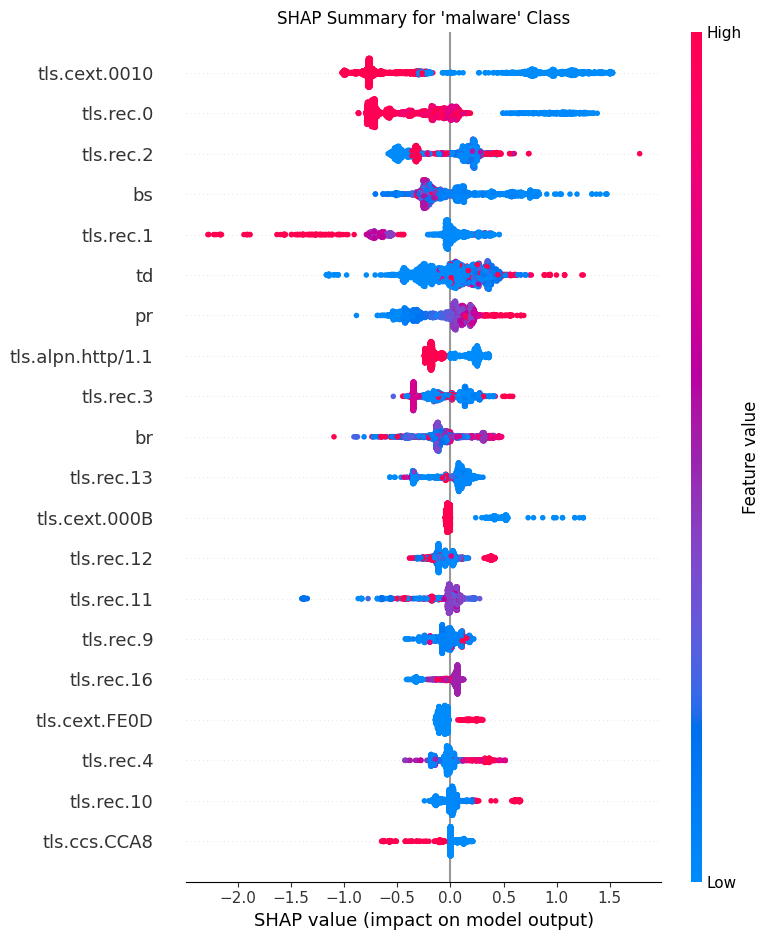

In [11]:
import matplotlib.pyplot as plt
import shap

def expand_feature_groups(group_combo):
    selected_features = []
    for group_name in group_combo:
        selected_features.extend(feature_groups[group_name])
    return selected_features

def extract_class_shap_values(shap_values, class_index):
    values = getattr(shap_values, "values", shap_values)
    if isinstance(values, list):
        return np.asarray(values[class_index])

    values = np.asarray(values)
    if values.ndim == 3:
        return values[:, :, class_index]
    if values.ndim == 2:
        return values

    raise ValueError(f"Unsupported SHAP value shape: {values.shape}")

best_row = overall_df.iloc[0]
best_group_combo = tuple(best_row["FeatureSet"].split(", "))
best_feature_set = expand_feature_groups(best_group_combo)

x_train_best = select_feature_set(preprocessor.transform(df_train), best_feature_set)
x_test_best = select_feature_set(preprocessor.transform(df_test), best_feature_set)
y_train_best = encode_labels(df_train_label["category"])

best_model = XGBoostBaseline(XGB_CONFIG_CANDIDATES[best_row["BestConfig"]])
best_model.fit(x_train_best, y_train_best)

background = x_train_best.sample(n=min(1000, len(x_train_best)), random_state=42)
explain_data = x_test_best.sample(n=min(2000, len(x_test_best)), random_state=42)

explainer = best_model.build_shap_explainer(background)
shap_values = best_model.explain(explain_data, explainer=explainer)

class_name = "malware"
class_index = CLASS_TO_INDEX[class_name]
class_shap_values = extract_class_shap_values(shap_values, class_index)

print(
    f"SHAP summary for feature set={best_row['FeatureSet']} "
    f"with config={best_row['BestConfig']} on class={class_name}."
)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    class_shap_values,
    explain_data,
    feature_names=explain_data.columns.tolist(),
    show=False,
)
plt.title(f"SHAP Summary for '{class_name}' Class")
plt.tight_layout()
plt.show()
